In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:

df = pd.read_csv("TN womens crime datasets.txt")

In [9]:
print(df.head())

   Year    District         Area  Crime_Type  Victim_Age     Time Urban_Rural  \
0  2021     Chennai      T Nagar        Rape          23    Night       Urban   
1  2021     Chennai    Velachery     Assault          31  Evening       Urban   
2  2021     Chennai     Tambaram  Kidnapping          17    Night       Urban   
3  2021  Coimbatore  Gandhipuram        Rape          26    Night       Urban   
4  2021  Coimbatore     RS Puram     Assault          35  Morning       Urban   

   Police_Station  Crime_Count  
0      T Nagar PS           18  
1    Velachery PS            9  
2     Tambaram PS           14  
3  Gandhipuram PS           20  
4     RS Puram PS            6  


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            125 non-null    int64 
 1   District        125 non-null    object
 2   Area            125 non-null    object
 3   Crime_Type      125 non-null    object
 4   Victim_Age      125 non-null    int64 
 5   Time            125 non-null    object
 6   Urban_Rural     125 non-null    object
 7   Police_Station  125 non-null    object
 8   Crime_Count     125 non-null    int64 
dtypes: int64(3), object(6)
memory usage: 5.9+ KB
None


In [11]:
print(df.isnull().sum())


Year              0
District          0
Area              0
Crime_Type        0
Victim_Age        0
Time              0
Urban_Rural       0
Police_Station    0
Crime_Count       0
dtype: int64


In [13]:

def safety_level(crime_count):

    if crime_count <= 5:
        return "Low"

    elif crime_count <= 15:
        return "Medium"

    else:
        return "High Danger"


In [14]:
df['Safety_Level'] = df['Crime_Count'].apply(safety_level)

In [15]:
print(df.head())

   Year    District         Area  Crime_Type  Victim_Age     Time Urban_Rural  \
0  2021     Chennai      T Nagar        Rape          23    Night       Urban   
1  2021     Chennai    Velachery     Assault          31  Evening       Urban   
2  2021     Chennai     Tambaram  Kidnapping          17    Night       Urban   
3  2021  Coimbatore  Gandhipuram        Rape          26    Night       Urban   
4  2021  Coimbatore     RS Puram     Assault          35  Morning       Urban   

   Police_Station  Crime_Count Safety_Level  
0      T Nagar PS           18  High Danger  
1    Velachery PS            9       Medium  
2     Tambaram PS           14       Medium  
3  Gandhipuram PS           20  High Danger  
4     RS Puram PS            6       Medium  


In [16]:
district_analysis = df.groupby('District')[
    'Crime_Count'
].sum()


In [18]:
top_10_districts = district_analysis.sort_values(
    ascending=False
).head(10)

print(top_10_districts)

District
Chennai       298
Coimbatore    155
Madurai       145
Trichy        106
Cuddalore     103
Tiruppur      100
Dindigul       82
Erode          80
Namakkal       80
Nilgiris       70
Name: Crime_Count, dtype: int64


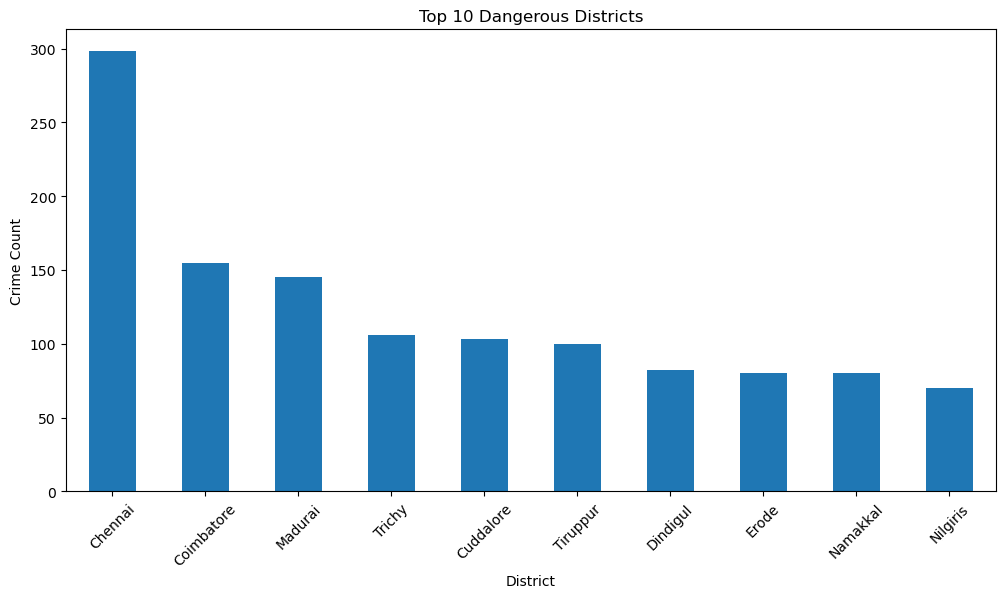

In [19]:
plt.figure(figsize=(12,6))

top_10_districts.plot(kind='bar')

plt.title("Top 10 Dangerous Districts")
plt.xlabel("District")
plt.ylabel("Crime Count")

plt.xticks(rotation=45)

plt.show()

In [20]:
rape_data = df[df['Crime_Type'] == 'Rape']

rape_by_district = rape_data.groupby(
    'District'
)['Crime_Count'].sum()

top_rape = rape_by_district.sort_values(
    ascending=False
).head(10)

print(top_rape)

District
Coimbatore    120
Chennai       114
Trichy        106
Cuddalore     103
Tiruppur      100
Madurai        95
Dindigul       82
Erode          80
Nilgiris       70
Name: Crime_Count, dtype: int64


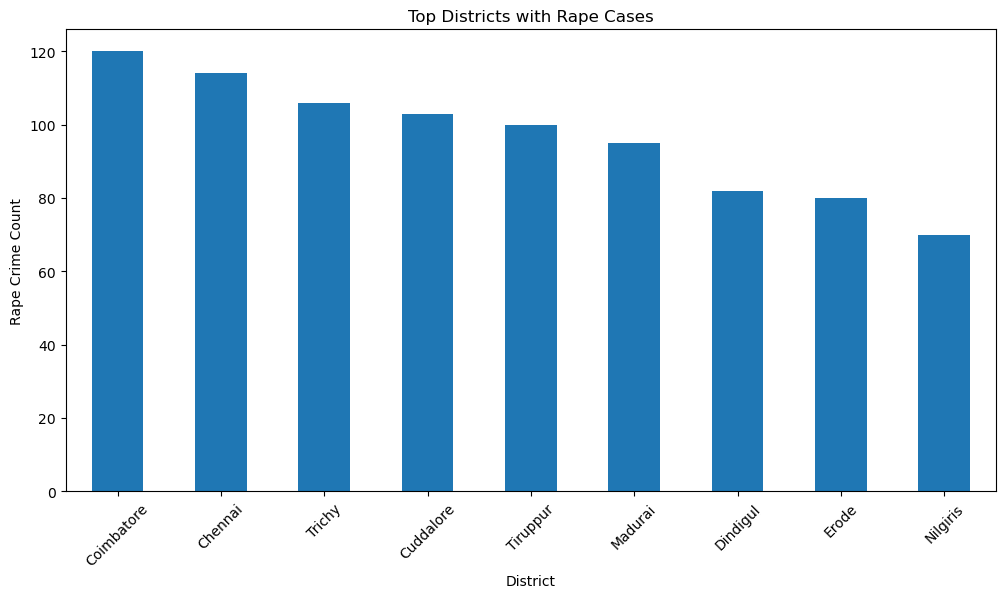

In [21]:
plt.figure(figsize=(12,6))

top_rape.plot(kind='bar')

plt.title("Top Districts with Rape Cases")
plt.xlabel("District")
plt.ylabel("Rape Crime Count")

plt.xticks(rotation=45)

plt.show()

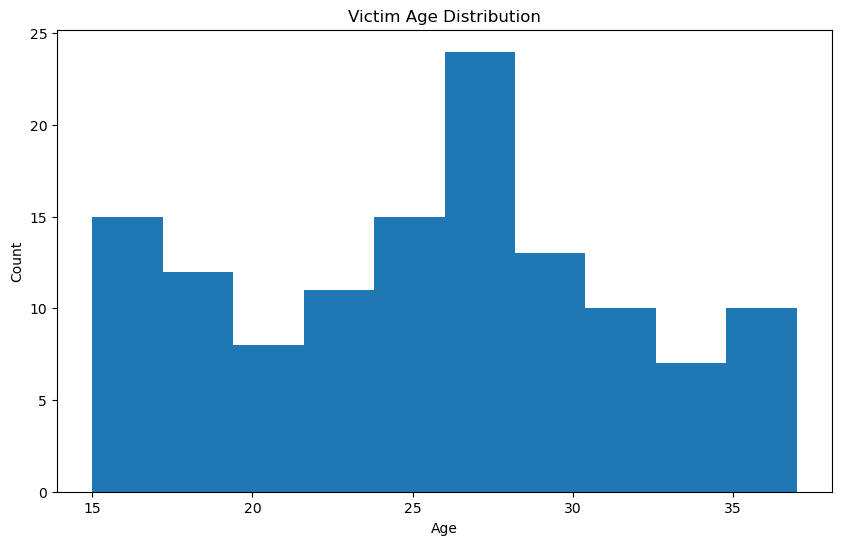

In [22]:
plt.figure(figsize=(10,6))

plt.hist(df['Victim_Age'])

plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

columns = [
    'District',
    'Area',
    'Crime_Type',
    'Time',
    'Urban_Rural',
    'Police_Station',
    'Safety_Level'
]

for col in columns:
    df[col] = le.fit_transform(df[col])



X = df[[
    'Year',
    'District',
    'Area',
    'Crime_Type',
    'Victim_Age',
    'Time',
    'Urban_Rural',
    'Police_Station',
    'Crime_Count'
]]

y = df['Safety_Level']


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
predictions = model.predict(X_test)

print(predictions)


[2 2 1 2 0 0 2 2 0 2 2 0 0 2 0 0 2 2 1 2 2 0 0 2 2]


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)


Accuracy : 1.0


In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(
    df[['Crime_Count', 'Victim_Age']]
)

print(df[['Crime_Count', 'Victim_Age', 'Cluster']].head())

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


   Crime_Count  Victim_Age  Cluster
0           18          23        1
1            9          31        0
2           14          17        2
3           20          26        1
4            6          35        0


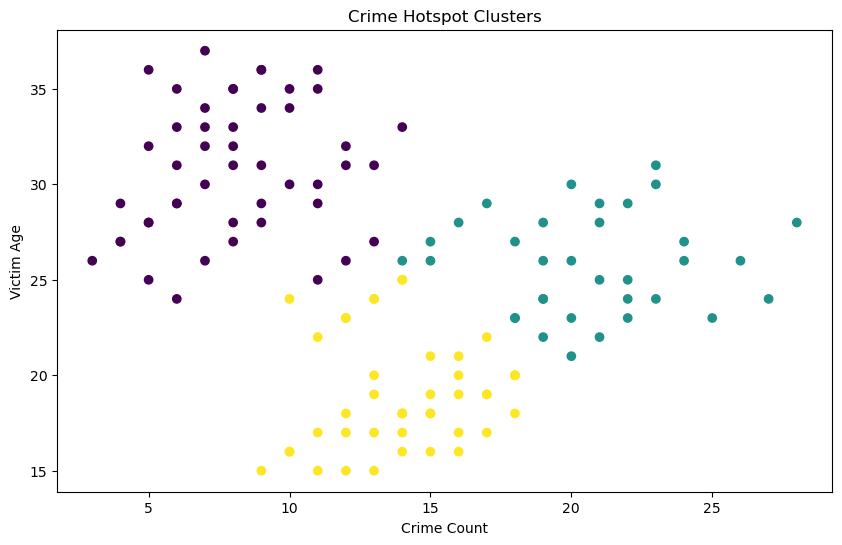

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Crime_Count'],
    df['Victim_Age'],
    c=df['Cluster']
)

plt.title("Crime Hotspot Clusters")
plt.xlabel("Crime Count")
plt.ylabel("Victim Age")

plt.show()